In [17]:
import pandas as pd
original_data = pd.read_excel(r'D:\JCE\data.xlsx')
original_data

,Temperature,Liquid phase concentration,Vapor phase concentration
0,350.85,0.0000,0.000
1,351.65,0.0361,0.030
2,354.15,0.2470,0.173
3,356.05,0.3220,0.194
4,358.35,0.5330,0.322
...,...,...,...
57,355.95,0.3760,0.204
58,357.45,0.3490,0.176
59,362.55,0.7360,0.533
60,363.95,0.6340,0.416


In [18]:
from sklearn.model_selection import train_test_split,GridSearchCV,ShuffleSplit
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
import copy
import time
ts = time.time()
x_data = original_data.iloc[:,:-1]
y_data = original_data.iloc[:,[-1]]
random_seed = [
    24,1379,
    3407,14122,38324,65536,98765
              ]

model_list = []
pred_dict =[]
mms_list = []
sss_list = []
score_dict = {'random_seed':[],'train_rmse':[],'train_r2':[],'test_rmse':[],'test_r2':[]}
y_train=pd.DataFrame()
y_pred=pd.DataFrame()
for i in random_seed:
    x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size=0.2,random_state =i)
    train_index = x_train.index.tolist()
    test_index = x_test.index.tolist()
    gscv = GridSearchCV(
        KernelRidge(kernel='rbf'),
        param_grid={
            'alpha':[1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1],
            'gamma':[i*1e-0 for i in range(1,15)]
        },
        cv = ShuffleSplit(n_splits=5,train_size=0.8,test_size=0.2,random_state=i),scoring='neg_root_mean_squared_error',n_jobs=8).fit(x_train,y_train)
    para = gscv.best_params_
    model = gscv.best_estimator_
    train_rmse = float(np.sqrt(mean_squared_error(y_train,model.predict(x_train))))
    train_r2 = float(r2_score(y_train,model.predict(x_train)))
    test_prediction = model.predict(x_test)
    test_rmse = float(np.sqrt(mean_squared_error(y_test,test_prediction)))
    test_r2 = float(r2_score(y_test,test_prediction))
    model_list.append({'seed':i,'para':para,'model':model})
    score_dict['random_seed'].append(i)
    score_dict['train_rmse'].append(str(round(train_rmse,4)))
    score_dict['train_r2'].append(str(round(train_r2,4)))
    score_dict['test_rmse'].append(str(round(test_rmse,4)))
    score_dict['test_r2'].append(str(round(test_r2,4)))
    pred_dict.append({
        'title':'random seed: '+str(i),
        'train':[y_train.values.ravel(),model.predict(x_train)],
        'test':[ y_test.values.ravel(),test_prediction.ravel()]})
te = time.time()
print('Model Training Performance: ')
pd.DataFrame().from_dict(score_dict).T

Model Training Performance: 


,0,1,2,3,4,5,6
random_seed,24,1379,3407,14122,38324,65536,98765
train_rmse,0.0329,0.0024,0.0142,0.0032,0.0043,0.0356,0.031
train_r2,0.9778,0.9999,0.9968,0.9998,0.9997,0.979,0.984
test_rmse,0.1375,0.0756,0.0376,0.0168,0.0412,0.0496,0.0727
test_r2,0.8128,0.8154,0.9718,0.9949,0.8782,0.9648,0.9262


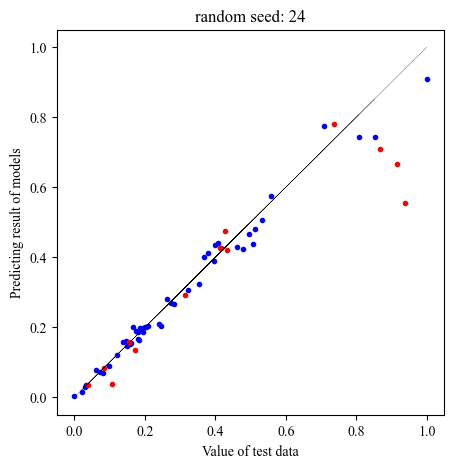

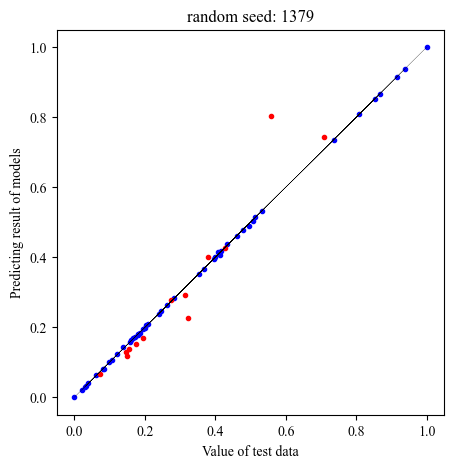

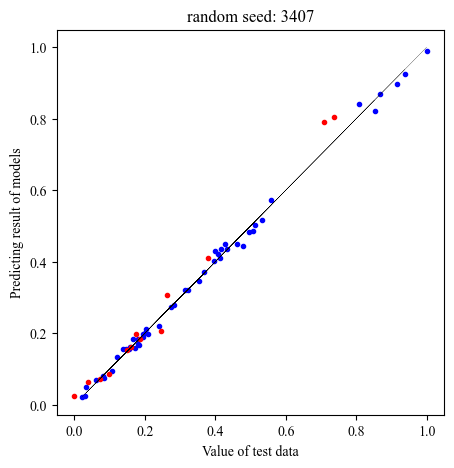

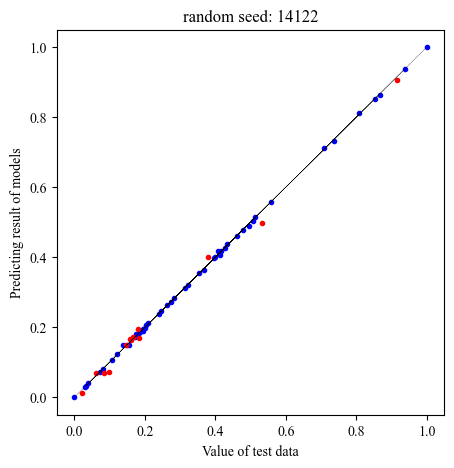

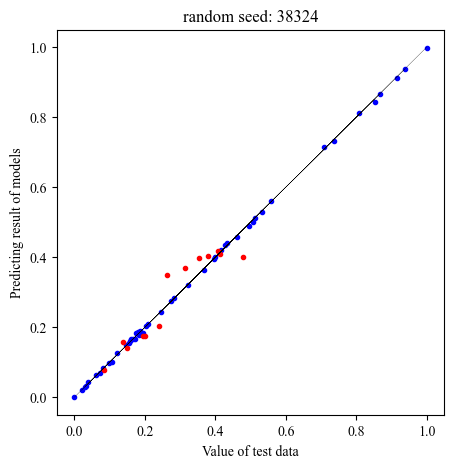

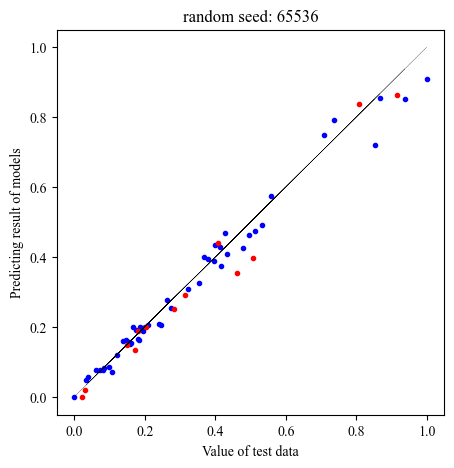

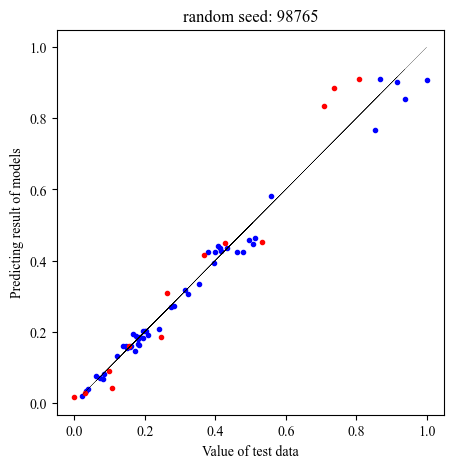

In [19]:
import matplotlib.pyplot as plt
for i in pred_dict:
    plt.figure(figsize=(5,5))
    plt.rc('font',family='Times New Roman')
    plt.plot(i['train'][0],i['train'][0],color='black',linewidth=0.1)
    plt.scatter(i['train'][0],i['train'][1],marker='.',color='blue',label='train')
    plt.scatter(i['test'][0],i['test'][1],marker='.',color='red',label='test')
    plt.ylabel('Predicting result of models')
    plt.xlabel('Value of test data')
    plt.title(i['title'])
    plt.show()

In [20]:
pred_data = pd.read_excel(r'D:\JCE\experiment.xlsx')
pred_ori = pred_data.loc[:,['Temperature','Liquid phase concentration']]
pred_ori.columns = ['Temperature','Liquid phase concentration']
pred_ori

,Temperature,Liquid phase concentration
0,350.85,0.000
1,353.15,0.145
2,353.55,0.175
3,354.65,0.223
4,355.25,0.275
5,356.45,0.331
6,358.15,0.445
7,359.25,0.512
8,361.55,0.576
9,362.35,0.634


In [21]:
pred_df = pd.DataFrame()
for curr_index,curr_model in enumerate(model_list):
    pred_data = copy.deepcopy(pred_ori)
    pred_index = pred_data.index.tolist()
    pred_columns = pred_data.columns.tolist()
    pred_result = pd.DataFrame(data=curr_model['model'].predict(pred_data),index=pred_index,columns=[curr_model['seed']])
    pred_df = pd.concat([pred_df,pred_result],axis=1,sort=False)
pred_df['pred_mean']=pred_df.mean(axis=1)
pred_df.to_excel(r'D:\JCE\data0325.xlsx')
pred_df

,24,1379,3407,14122,38324,65536,98765,pred_mean
0,0.004688,0.000050,0.022952,-0.000005,-0.000012,-0.001223,0.015440,0.005984
1,0.073385,0.087984,0.078263,0.078126,0.087214,0.077147,0.071704,0.079118
2,0.095597,0.111871,0.094498,0.076257,0.109029,0.092214,0.097442,0.096701
3,0.153579,0.110887,0.151599,0.137828,0.140392,0.153563,0.157011,0.143551
4,0.169693,0.180518,0.173716,0.182805,0.183913,0.168993,0.167783,0.175346
5,0.203506,0.188465,0.193988,0.189636,0.172501,0.203062,0.199110,0.192896
6,0.271811,0.124510,0.287888,0.228849,0.256775,0.271674,0.274825,0.245190
7,0.293153,0.290807,0.319126,0.305163,0.367823,0.290199,0.316714,0.311855
8,0.415507,0.326776,0.400917,0.363853,0.370026,0.416048,0.417458,0.387226
9,0.484396,0.361212,0.437868,0.338388,0.436848,0.470556,0.431718,0.422998
